
================ FIT RESULTS ================

Pic 1
  Kd    = 32.8688 ± 819.8764
  dmax  = 0.063860 ± 0.468343 ppm
  R²    = -1.2719

Pic 2
  Kd    = 23592.5776 ± 3338613.2447
  dmax  = 10.997027 ± 1547.283733 ppm
  R²    = 0.9080

Pic 3
  Kd    = 16.3796 ± 121.1113
  dmax  = 0.068847 ± 0.100040 ppm
  R²    = 0.4568

Pic 4
  Kd    = 119562.8194 ± 3788919.1958
  dmax  = 23.598051 ± 739.250945 ppm
  R²    = 0.9698

Pic 5
  Kd    = 117.9478 ± 342.4193
  dmax  = 0.066154 ± 0.045197 ppm
  R²    = 0.8989

Pic 6
  Kd    = 45663.5119 ± 9710162.5613
  dmax  = 8.838800 ± 1856.326837 ppm
  R²    = 0.8635

Pic 7
  Kd    = 260.8168 ± 1512.8679
  dmax  = 0.126817 ± 0.161719 ppm
  R²    = 0.4716

Pic 8
  Kd    = 0.0691 ± 527.3735
  dmax  = 99.889356 ± 760987.044531 ppm
  R²    = -3.0970

Pic 9
  Kd    = 10.4436 ± 181.6109
  dmax  = 0.887169 ± 13.274059 ppm
  R²    = 0.3801



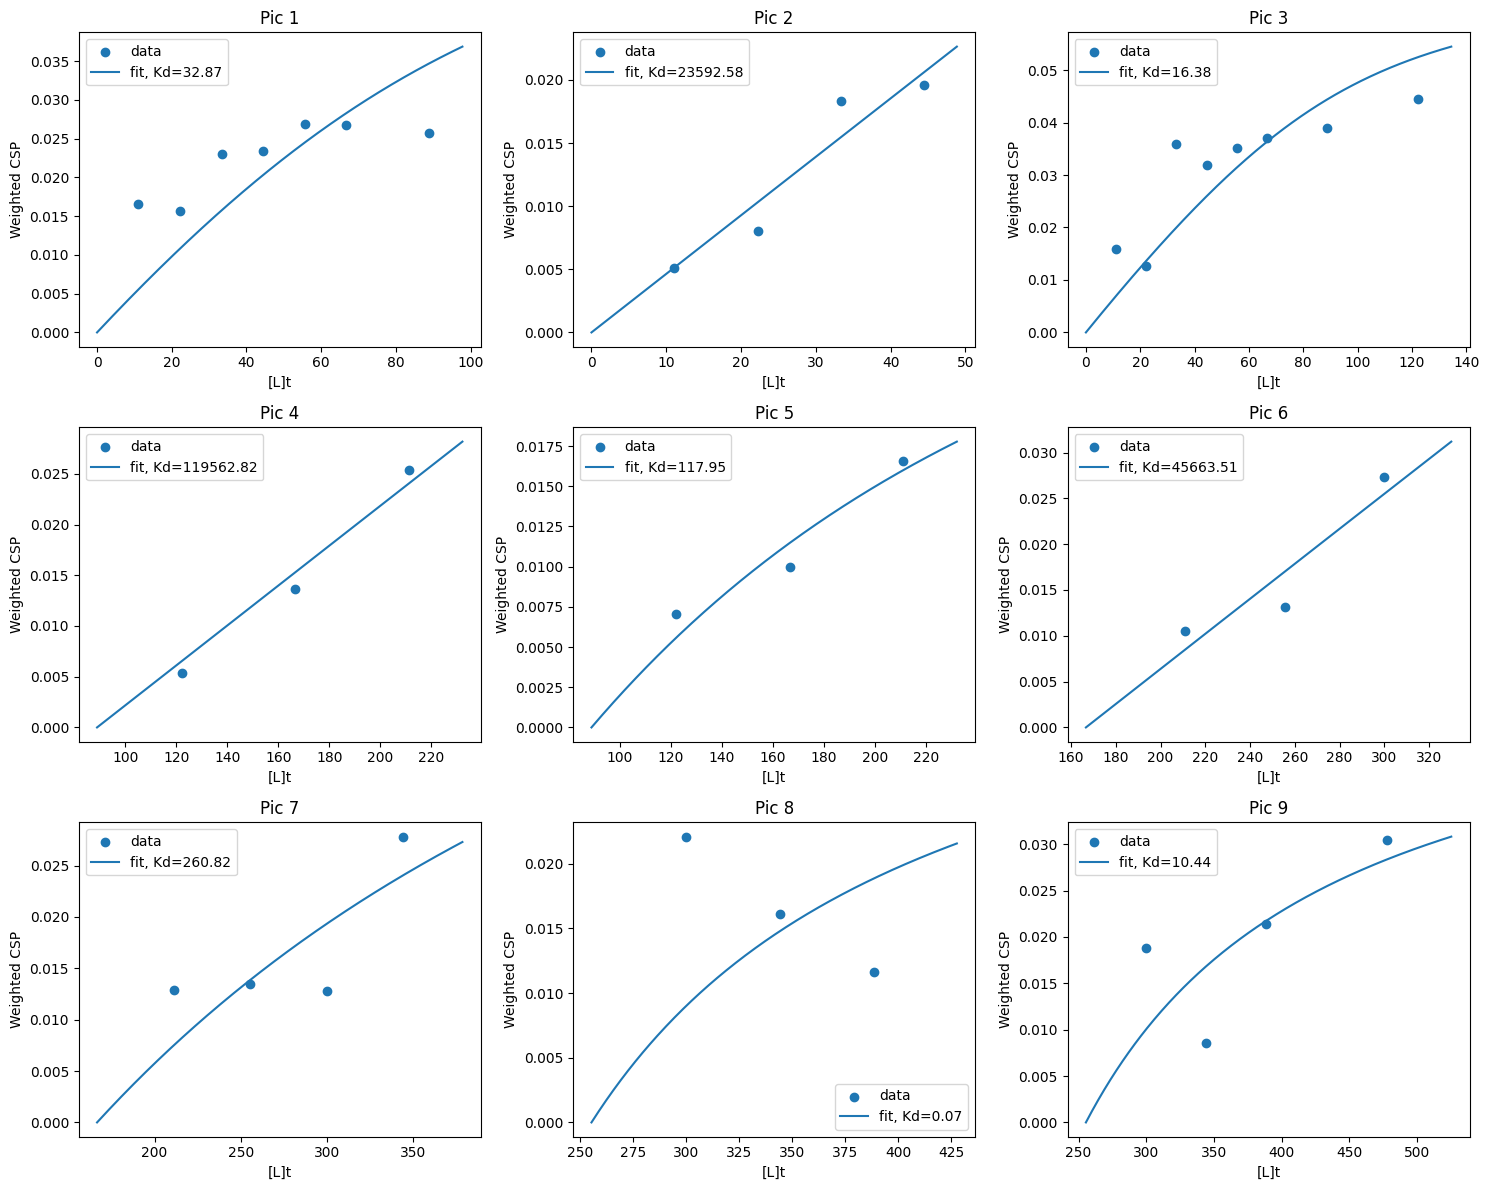

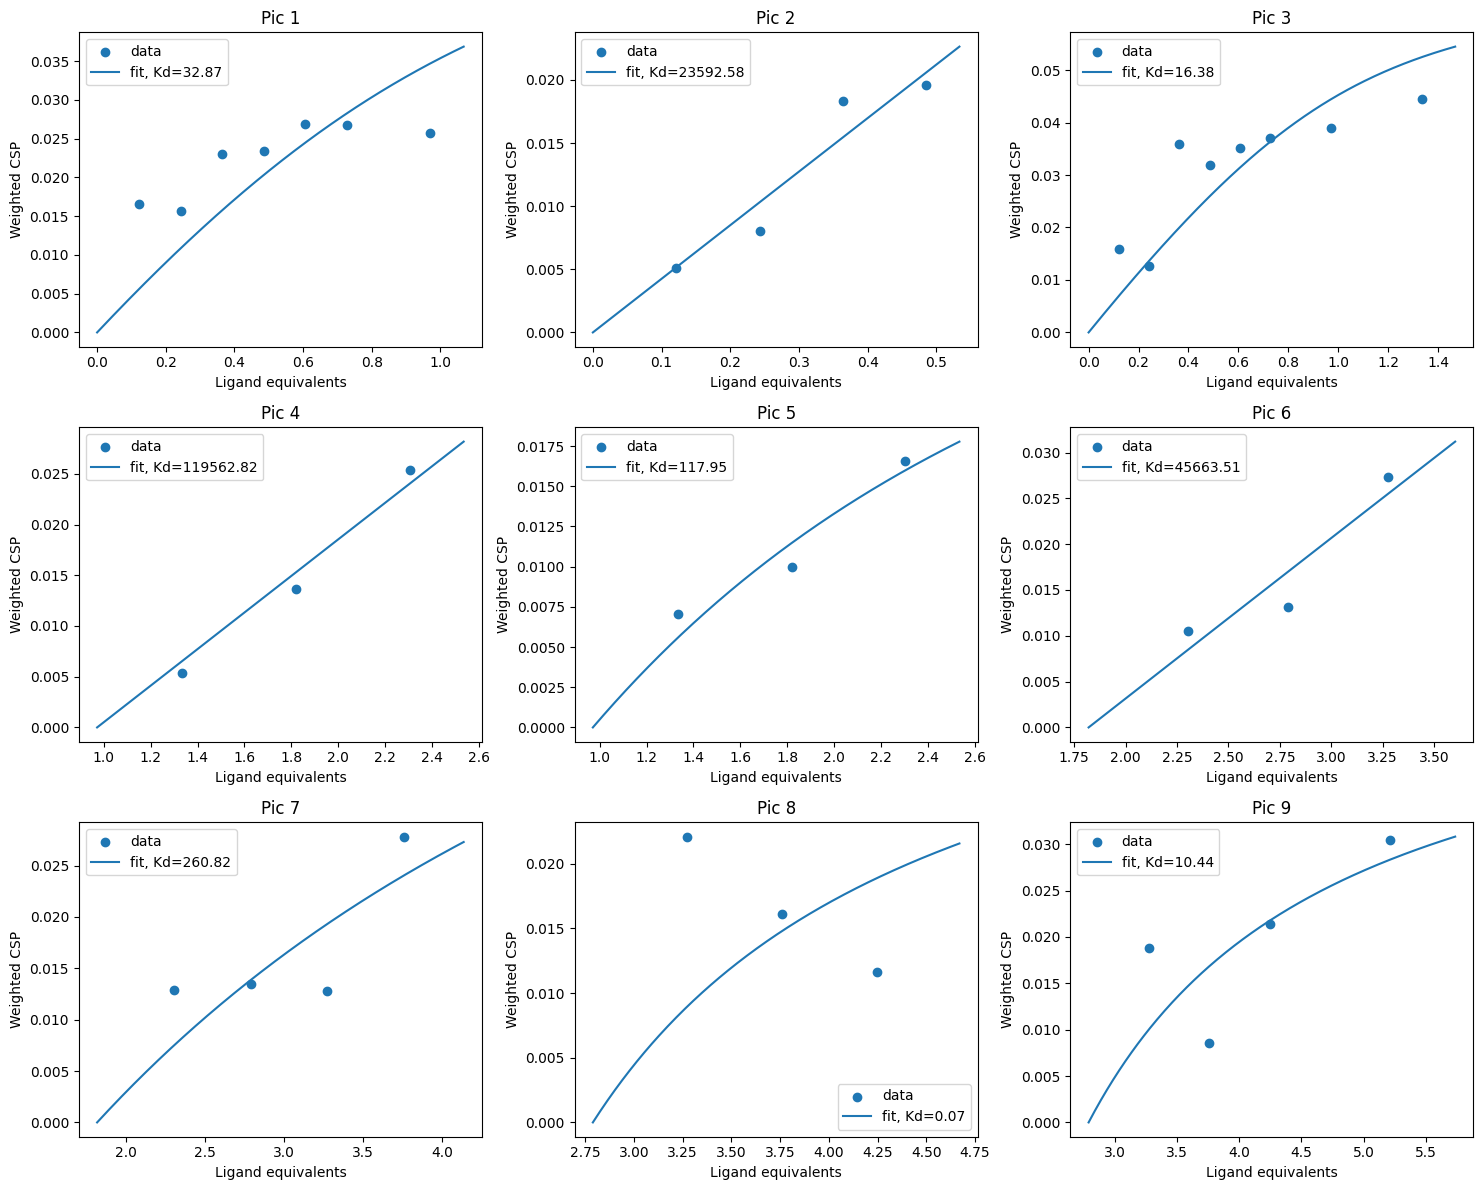

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ============================================================
# PARAMETRES GENERAUX
# ============================================================

# Concentration totale en protéine
# IMPORTANT: le Kd sera dans la même unité
Pt = 91.56   # [µM]

# Pondération 15N
alpha = 0.2   # équivaut à deltaN / 5

# Si tu veux la formule du paper avec sqrt(1/2), mets True
use_half_factor = True

# ============================================================
# DONNEES
# ref_equiv = équivalent à partir duquel les déplacements ont été mesurés
# ============================================================

data = {
    "Pic 1": {
        "ref_equiv": 0.000,
        "equiv":  [0.121, 0.243, 0.364, 0.485, 0.607, 0.728, 0.971],
        "deltaH": [0.0235, 0.0216, 0.0303, 0.0305, 0.0352, 0.0330, 0.0308],
        "deltaN": [0.0040, 0.0243, 0.0607, 0.0648, 0.0729, 0.0931, 0.0972],
    },
    "Pic 2": {
        "ref_equiv": 0.000,
        "equiv":  [0.121, 0.243, 0.364, 0.485],
        "deltaH": [0.0066, 0.0102, 0.0237, 0.0250],
        "deltaN": [0.0140, 0.0246, 0.0527, 0.0597],
    },
    "Pic 3": {
        "ref_equiv": 0.000,
        "equiv":  [0.121, 0.243, 0.364, 0.485, 0.607, 0.728, 0.971, 1.335],
        "deltaH": [0.00302, 0.00645, 0.01533, 0.02111, 0.01525, 0.02028, 0.02614, 0.03067],
        "deltaN": [0.11159, 0.08369, 0.24177, 0.19993, 0.23712, 0.24177, 0.24177, 0.27432],
    },
    "Pic 4": {
        "ref_equiv": 0.971,
        "equiv":  [1.335, 1.820, 2.305],
        "deltaH": [0.00491, 0.00771, 0.00014],
        "deltaN": [0.02938, 0.08814, 0.17974],
    },
    "Pic 5": {
        "ref_equiv": 0.971,
        "equiv":  [1.335, 1.820, 2.305],
        "deltaH": [0.00756, 0.01407, 0.01625],
        "deltaN": [0.03263, 0.00000, 0.08445],
    },
    "Pic 6": {
        "ref_equiv": 1.820,
        "equiv":  [2.305, 2.790, 3.275],
        "deltaH": [0.00769, 0.00392, 0.01866],
        "deltaN": [0.06361, 0.09087, 0.16962],
    },
    "Pic 7": {
        "ref_equiv": 1.820,
        "equiv":  [2.305, 2.790, 3.275, 3.760],
        "deltaH": [0.01736, 0.01845, 0.01790, 0.03933],
        "deltaN": [0.02838, 0.02390, 0.01344, 0.00000],
    },
    "Pic 8": {
        "ref_equiv": 2.790,
        "equiv":  [3.275, 3.760, 4.245],
        "deltaH": [0.03123, 0.01663, 0.01639],
        "deltaN": [0.00445, 0.07789, 0.00445],
    },
    "Pic 9": {
        "ref_equiv": 2.790,
        "equiv":  [3.275, 3.760, 4.245, 5.215],
        "deltaH": [0.02593, 0.01207, 0.03011, 0.04087],
        "deltaN": [0.03016, 0.00335, 0.01508, 0.06702],
    },
}

# ============================================================
# FONCTIONS
# ============================================================

def weighted_csp(deltaH, deltaN, alpha=0.2, use_half_factor=False):
    deltaH = np.asarray(deltaH, dtype=float)
    deltaN = np.asarray(deltaN, dtype=float)
    if use_half_factor:
        return np.sqrt(0.5 * (deltaH**2 + (alpha * deltaN)**2))
    return np.sqrt(deltaH**2 + (alpha * deltaN)**2)

def frac_bound(Lt, Kd, Pt):
    term = (Pt + Lt + Kd) - np.sqrt((Pt + Lt + Kd)**2 - 4.0 * Pt * Lt)
    return term / (2.0 * Pt)

def local_csp_model(Lt, Kd, dmax, Pt, Lt_ref):
    """
    Modèle adapté à des données mesurées par rapport à un point de référence Lt_ref
    """
    return dmax * (frac_bound(Lt, Kd, Pt) - frac_bound(Lt_ref, Kd, Pt))

def fit_one_peak(equiv, deltaH, deltaN, ref_equiv, Pt, alpha=0.2, use_half_factor=False):
    equiv = np.asarray(equiv, dtype=float)
    Lt = equiv * Pt
    Lt_ref = ref_equiv * Pt

    y = weighted_csp(deltaH, deltaN, alpha=alpha, use_half_factor=use_half_factor)

    def fit_func(Lt, Kd, dmax):
        return local_csp_model(Lt, Kd, dmax, Pt, Lt_ref)

    # guesses initiales
    p0 = [Pt, max(np.max(y) * 2.0, 1e-4)]

    # bornes
    bounds = ([1e-9, 0.0], [1e9, 100.0])

    popt, pcov = curve_fit(fit_func, Lt, y, p0=p0, bounds=bounds, maxfev=20000)
    Kd_fit, dmax_fit = popt
    perr = np.sqrt(np.diag(pcov))
    Kd_err, dmax_err = perr

    # qualité du fit
    y_fit = fit_func(Lt, *popt)
    ss_res = np.sum((y - y_fit)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    return {
        "equiv": equiv,
        "Lt": Lt,
        "Lt_ref": Lt_ref,
        "y": y,
        "Kd": Kd_fit,
        "Kd_err": Kd_err,
        "dmax": dmax_fit,
        "dmax_err": dmax_err,
        "r2": r2,
        "y_fit": y_fit,
    }

# ============================================================
# FIT DE TOUS LES PICS
# ============================================================

results = {}

for name, d in data.items():
    try:
        res = fit_one_peak(
            equiv=d["equiv"],
            deltaH=d["deltaH"],
            deltaN=d["deltaN"],
            ref_equiv=d["ref_equiv"],
            Pt=Pt,
            alpha=alpha,
            use_half_factor=use_half_factor
        )
        results[name] = res
    except Exception as e:
        print(f"{name}: fit failed -> {e}")

# ============================================================
# AFFICHAGE DES RESULTATS
# ============================================================

print("\n================ FIT RESULTS ================\n")
for name, res in results.items():
    print(f"{name}")
    print(f"  Kd    = {res['Kd']:.4f} ± {res['Kd_err']:.4f}")
    print(f"  dmax  = {res['dmax']:.6f} ± {res['dmax_err']:.6f} ppm")
    print(f"  R²    = {res['r2']:.4f}")
    print()

# ============================================================
# PLOTS INDIVIDUELS
# ============================================================

n = len(results)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = np.array(axes).reshape(-1)

for ax, (name, res) in zip(axes, results.items()):
    Lt_plot = np.linspace(min(res["Lt_ref"], res["Lt"].min()), res["Lt"].max() * 1.1, 300)
    y_plot = local_csp_model(Lt_plot, res["Kd"], res["dmax"], Pt, res["Lt_ref"])

    ax.scatter(res["Lt"], res["y"], label="data")
    ax.plot(Lt_plot, y_plot, label=f"fit, Kd={res['Kd']:.2f}")
    ax.set_title(name)
    ax.set_xlabel("[L]t")
    ax.set_ylabel("Weighted CSP")
    ax.legend()

# cacher les axes vides
for i in range(len(results), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# PLOT EN EQUIVALENTS (optionnel)
# ============================================================

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = np.array(axes).reshape(-1)

for ax, (name, res) in zip(axes, results.items()):
    equiv_plot = np.linspace(min(res["Lt_ref"] / Pt, res["equiv"].min()), res["equiv"].max() * 1.1, 300)
    Lt_plot = equiv_plot * Pt
    y_plot = local_csp_model(Lt_plot, res["Kd"], res["dmax"], Pt, res["Lt_ref"])

    ax.scatter(res["equiv"], res["y"], label="data")
    ax.plot(equiv_plot, y_plot, label=f"fit, Kd={res['Kd']:.2f}")
    ax.set_title(name)
    ax.set_xlabel("Ligand equivalents")
    ax.set_ylabel("Weighted CSP")
    ax.legend()

for i in range(len(results), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()


================ GLOBAL FIT RESULTS ================

Kd global = 28.2045  (même unité que Pt)
Global R² = 0.6358

Pic 1
  dmax = 0.061152 ppm
  ref_equiv = 0.0

Pic 2
  dmax = 0.060680 ppm
  ref_equiv = 0.0

Pic 3
  dmax = 0.077877 ppm
  ref_equiv = 0.0

Pic 4
  dmax = 0.081686 ppm
  ref_equiv = 0.971

Pic 5
  dmax = 0.058314 ppm
  ref_equiv = 0.971

Pic 6
  dmax = 0.203727 ppm
  ref_equiv = 1.82

Pic 7
  dmax = 0.171432 ppm
  ref_equiv = 1.82

Pic 8
  dmax = 0.356938 ppm
  ref_equiv = 2.79

Pic 9
  dmax = 0.407268 ppm
  ref_equiv = 2.79



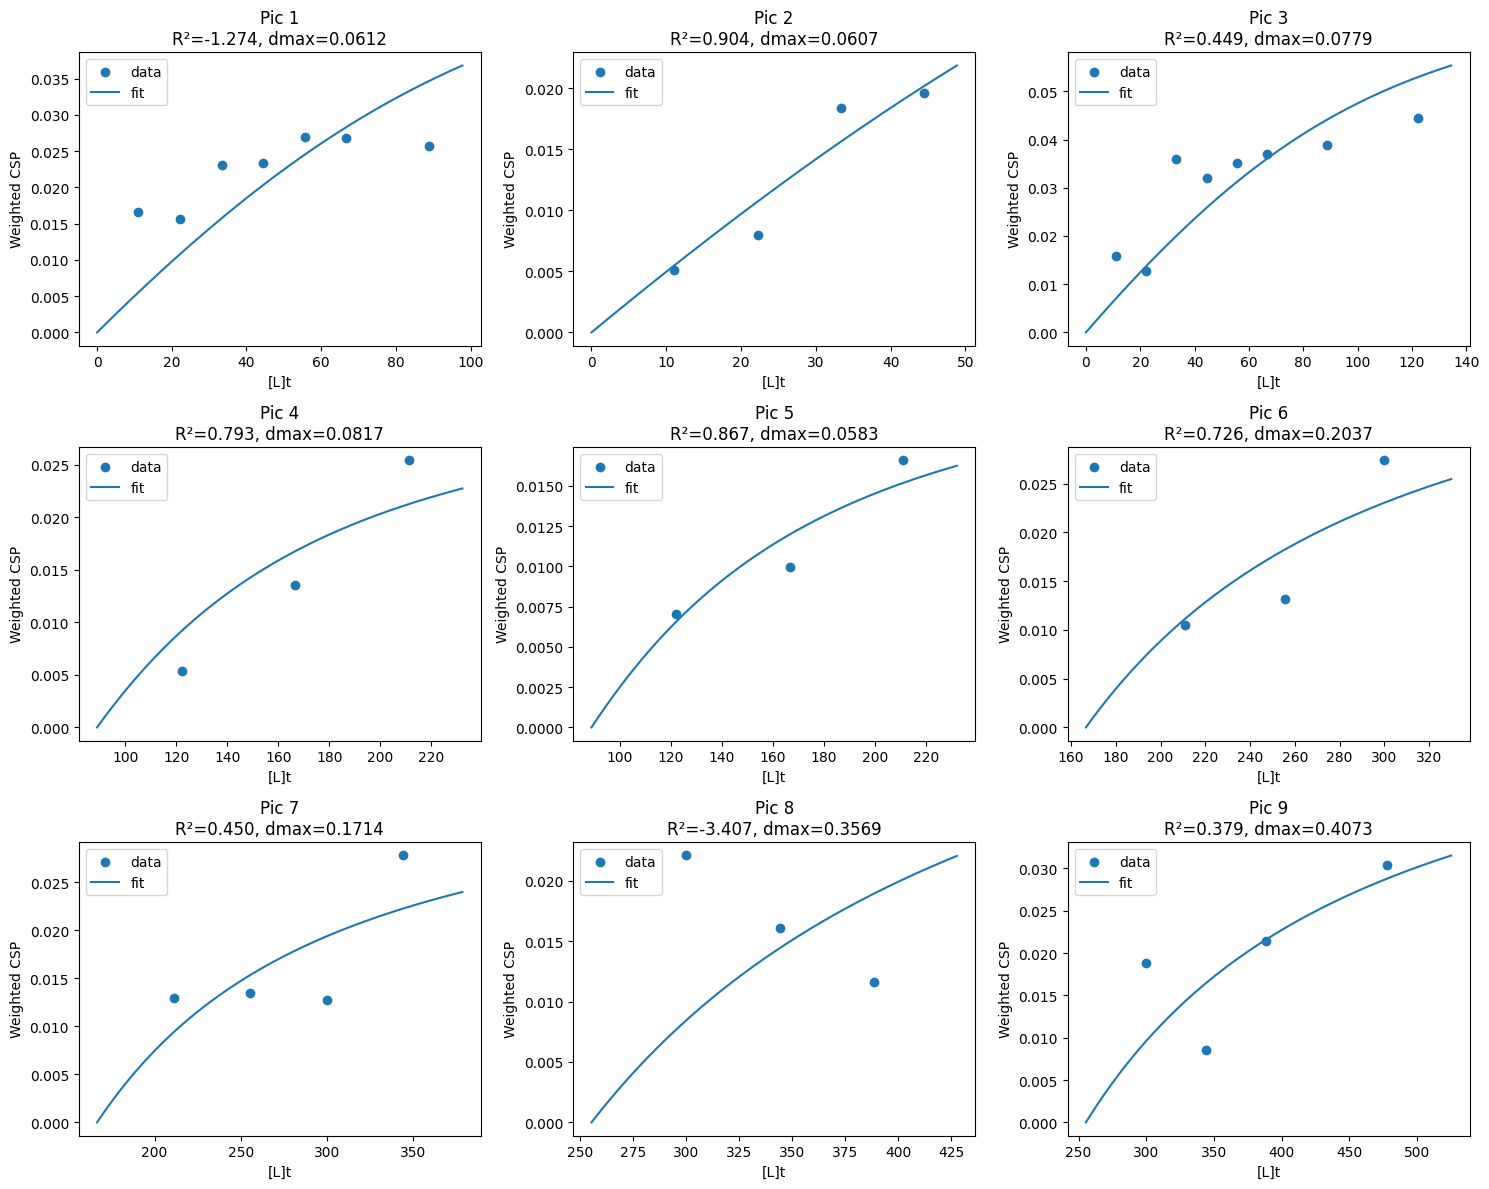

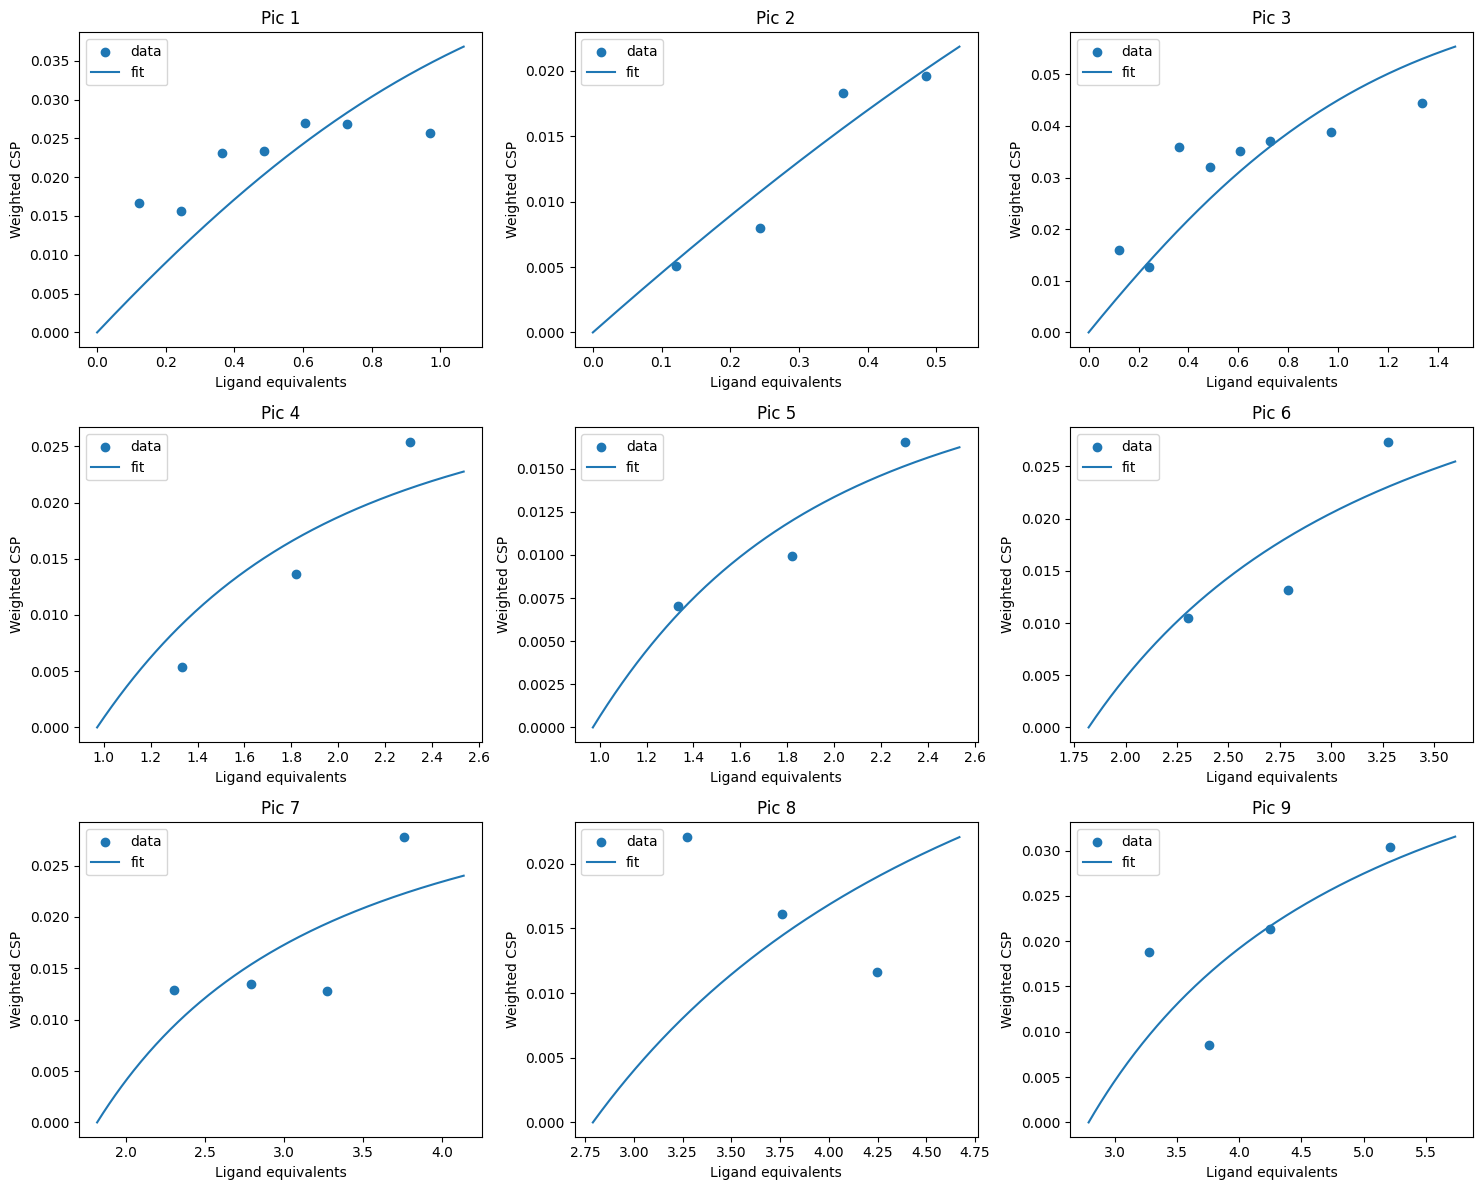

Results written to global_fit_results.txt


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

# ============================================================
# PARAMETRES GENERAUX
# ============================================================

# Concentration totale en protéine
# Le Kd sortira dans la même unité
Pt = 91.56   # ex: 50 µM

# Pondération du 15N
alpha = 0.2   # équivaut à deltaN / 5

# Si tu veux inclure le facteur 1/2 du paper, mets True
use_half_factor = True

# ============================================================
# DONNEES
# ref_equiv = équivalent à partir duquel les déplacements ont été mesurés
# ============================================================

data = {
    "Pic 1": {
        "ref_equiv": 0.000,
        "equiv":  [0.121, 0.243, 0.364, 0.485, 0.607, 0.728, 0.971],
        "deltaH": [0.0235, 0.0216, 0.0303, 0.0305, 0.0352, 0.0330, 0.0308],
        "deltaN": [0.0040, 0.0243, 0.0607, 0.0648, 0.0729, 0.0931, 0.0972],
    },
    "Pic 2": {
        "ref_equiv": 0.000,
        "equiv":  [0.121, 0.243, 0.364, 0.485],
        "deltaH": [0.0066, 0.0102, 0.0237, 0.0250],
        "deltaN": [0.0140, 0.0246, 0.0527, 0.0597],
    },
    "Pic 3": {
        "ref_equiv": 0.000,
        "equiv":  [0.121, 0.243, 0.364, 0.485, 0.607, 0.728, 0.971, 1.335],
        "deltaH": [0.00302, 0.00645, 0.01533, 0.02111, 0.01525, 0.02028, 0.02614, 0.03067],
        "deltaN": [0.11159, 0.08369, 0.24177, 0.19993, 0.23712, 0.24177, 0.24177, 0.27432],
    },
    "Pic 4": {
        "ref_equiv": 0.971,
        "equiv":  [1.335, 1.820, 2.305],
        "deltaH": [0.00491, 0.00771, 0.00014],
        "deltaN": [0.02938, 0.08814, 0.17974],
    },
    "Pic 5": {
        "ref_equiv": 0.971,
        "equiv":  [1.335, 1.820, 2.305],
        "deltaH": [0.00756, 0.01407, 0.01625],
        "deltaN": [0.03263, 0.00000, 0.08445],
    },
    "Pic 6": {
        "ref_equiv": 1.820,
        "equiv":  [2.305, 2.790, 3.275],
        "deltaH": [0.00769, 0.00392, 0.01866],
        "deltaN": [0.06361, 0.09087, 0.16962],
    },
    "Pic 7": {
        "ref_equiv": 1.820,
        "equiv":  [2.305, 2.790, 3.275, 3.760],
        "deltaH": [0.01736, 0.01845, 0.01790, 0.03933],
        "deltaN": [0.02838, 0.02390, 0.01344, 0.00000],
    },
    "Pic 8": {
        "ref_equiv": 2.790,
        "equiv":  [3.275, 3.760, 4.245],
        "deltaH": [0.03123, 0.01663, 0.01639],
        "deltaN": [0.00445, 0.07789, 0.00445],
    },
    "Pic 9": {
        "ref_equiv": 2.790,
        "equiv":  [3.275, 3.760, 4.245, 5.215],
        "deltaH": [0.02593, 0.01207, 0.03011, 0.04087],
        "deltaN": [0.03016, 0.00335, 0.01508, 0.06702],
    },
}

# ============================================================
# FONCTIONS
# ============================================================

def weighted_csp(deltaH, deltaN, alpha=0.2, use_half_factor=False):
    deltaH = np.asarray(deltaH, dtype=float)
    deltaN = np.asarray(deltaN, dtype=float)
    if use_half_factor:
        return np.sqrt(0.5 * (deltaH**2 + (alpha * deltaN)**2))
    return np.sqrt(deltaH**2 + (alpha * deltaN)**2)

def frac_bound(Lt, Kd, Pt):
    term = (Pt + Lt + Kd) - np.sqrt((Pt + Lt + Kd)**2 - 4.0 * Pt * Lt)
    return term / (2.0 * Pt)

def local_model(Lt, Kd, dmax, Pt, Lt_ref):
    return dmax * (frac_bound(Lt, Kd, Pt) - frac_bound(Lt_ref, Kd, Pt))

# Préparation des données
peak_names = list(data.keys())
y_exp = {}
Lt_vals = {}
Lt_refs = {}

for name, d in data.items():
    equiv = np.asarray(d["equiv"], dtype=float)
    deltaH = np.asarray(d["deltaH"], dtype=float)
    deltaN = np.asarray(d["deltaN"], dtype=float)

    y_exp[name] = weighted_csp(deltaH, deltaN, alpha=alpha, use_half_factor=use_half_factor)
    Lt_vals[name] = equiv * Pt
    Lt_refs[name] = d["ref_equiv"] * Pt

# ============================================================
# GLOBAL FIT
# paramètre global = Kd
# paramètres locaux = dmax pour chaque pic
# params = [Kd, dmax_1, dmax_2, ..., dmax_n]
# ============================================================

def residuals(params):
    Kd = params[0]
    dmax_list = params[1:]

    res = []
    for i, name in enumerate(peak_names):
        dmax = dmax_list[i]
        y_calc = local_model(Lt_vals[name], Kd, dmax, Pt, Lt_refs[name])
        res.extend(y_calc - y_exp[name])
    return np.array(res)

# Guess initial
Kd_guess = Pt
dmax_guesses = [max(np.max(y_exp[name]) * 2.0, 1e-4) for name in peak_names]
x0 = np.array([Kd_guess] + dmax_guesses)

# Bornes
lower_bounds = [1e-9] + [0.0] * len(peak_names)
upper_bounds = [1e9] + [100.0] * len(peak_names)

result = least_squares(
    residuals,
    x0=x0,
    bounds=(lower_bounds, upper_bounds),
    max_nfev=50000
)

params_fit = result.x
Kd_global = params_fit[0]
dmax_global = params_fit[1:]

# ============================================================
# CALCUL D'UN R² GLOBAL
# ============================================================

all_exp = []
all_fit = []

for i, name in enumerate(peak_names):
    y_fit = local_model(Lt_vals[name], Kd_global, dmax_global[i], Pt, Lt_refs[name])
    all_exp.extend(y_exp[name])
    all_fit.extend(y_fit)

all_exp = np.array(all_exp)
all_fit = np.array(all_fit)

ss_res = np.sum((all_exp - all_fit)**2)
ss_tot = np.sum((all_exp - np.mean(all_exp))**2)
r2_global = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

# ============================================================
# AFFICHAGE DES RESULTATS
# ============================================================

print("\n================ GLOBAL FIT RESULTS ================\n")
print(f"Kd global = {Kd_global:.4f}  (même unité que Pt)")
print(f"Global R² = {r2_global:.4f}\n")

for i, name in enumerate(peak_names):
    print(f"{name}")
    print(f"  dmax = {dmax_global[i]:.6f} ppm")
    print(f"  ref_equiv = {data[name]['ref_equiv']}")
    print()

# ============================================================
# PLOTS INDIVIDUELS
# ============================================================

n = len(peak_names)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = np.array(axes).reshape(-1)

for ax, name, dmax in zip(axes, peak_names, dmax_global):
    Lt_min = min(Lt_refs[name], np.min(Lt_vals[name]))
    Lt_max = np.max(Lt_vals[name]) * 1.1
    Lt_plot = np.linspace(Lt_min, Lt_max, 300)

    y_plot = local_model(Lt_plot, Kd_global, dmax, Pt, Lt_refs[name])
    y_fit_pts = local_model(Lt_vals[name], Kd_global, dmax, Pt, Lt_refs[name])

    # R² local indicatif
    y = y_exp[name]
    ss_res_local = np.sum((y - y_fit_pts)**2)
    ss_tot_local = np.sum((y - np.mean(y))**2)
    r2_local = 1 - ss_res_local / ss_tot_local if ss_tot_local > 0 else np.nan

    ax.scatter(Lt_vals[name], y_exp[name], label="data")
    ax.plot(Lt_plot, y_plot, label=f"fit")
    ax.set_title(f"{name}\nR²={r2_local:.3f}, dmax={dmax:.4f}")
    ax.set_xlabel("[L]t")
    ax.set_ylabel("Weighted CSP")
    ax.legend()

for i in range(len(peak_names), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# VERSION AVEC AXE EN EQUIVALENTS
# ============================================================

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = np.array(axes).reshape(-1)

for ax, name, dmax in zip(axes, peak_names, dmax_global):
    eq_min = min(data[name]["ref_equiv"], np.min(data[name]["equiv"]))
    eq_max = np.max(data[name]["equiv"]) * 1.1
    eq_plot = np.linspace(eq_min, eq_max, 300)
    Lt_plot = eq_plot * Pt

    y_plot = local_model(Lt_plot, Kd_global, dmax, Pt, Lt_refs[name])

    ax.scatter(data[name]["equiv"], y_exp[name], label="data")
    ax.plot(eq_plot, y_plot, label=f"fit")
    ax.set_title(f"{name}")
    ax.set_xlabel("Ligand equivalents")
    ax.set_ylabel("Weighted CSP")
    ax.legend()

for i in range(len(peak_names), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# SAUVEGARDE TEXTE
# ============================================================

with open("global_fit_results.txt", "w", encoding="utf-8") as f:
    f.write("================ GLOBAL FIT RESULTS ================\n\n")
    f.write(f"Kd global = {Kd_global:.6f} (same unit as Pt)\n")
    f.write(f"Global R² = {r2_global:.6f}\n\n")
    for i, name in enumerate(peak_names):
        f.write(f"{name}\n")
        f.write(f"  dmax = {dmax_global[i]:.6f} ppm\n")
        f.write(f"  ref_equiv = {data[name]['ref_equiv']}\n\n")

print("Results written to global_fit_results.txt")

### Vraie concentration calmodulin avec équivalent corrigés en dessous:


================ FIT RESULTS ================

Peak 1
  Kd    = 12.9439 ± 140.1299
  dmax  = 0.045291 ± 0.099095 ppm
  R²    = -0.8813

Peak 2
  Kd    = 33714.4061 ± 1608036.2770
  dmax  = 15.623301 ± 741.965082 ppm
  R²    = 0.9082

Peak 3
  Kd    = 4.5710 ± 16.4815
  dmax  = 0.051672 ± 0.019200 ppm
  R²    = 0.6263

Peak 4
  Kd    = 86502.5680 ± 3673142.7680
  dmax  = 17.041392 ± 715.843066 ppm
  R²    = 0.9696

Peak 5
  Kd    = 129.1933 ± 354.4622
  dmax  = 0.068280 ± 0.040248 ppm
  R²    = 0.8997

Peak 6
  Kd    = 91326.6812 ± 6181686.6126
  dmax  = 17.527428 ± 1185.569905 ppm
  R²    = 0.8636

Peak 7
  Kd    = 257.4134 ± 1448.1295
  dmax  = 0.127500 ± 0.133393 ppm
  R²    = 0.4724

Peak 8
  Kd    = 0.0862 ± 754.7957
  dmax  = 97.018588 ± 848168.079337 ppm
  R²    = -3.2235

Peak 9
  Kd    = 1.4332 ± 206.2776
  dmax  = 6.821485 ± 964.908593 ppm
  R²    = 0.3808



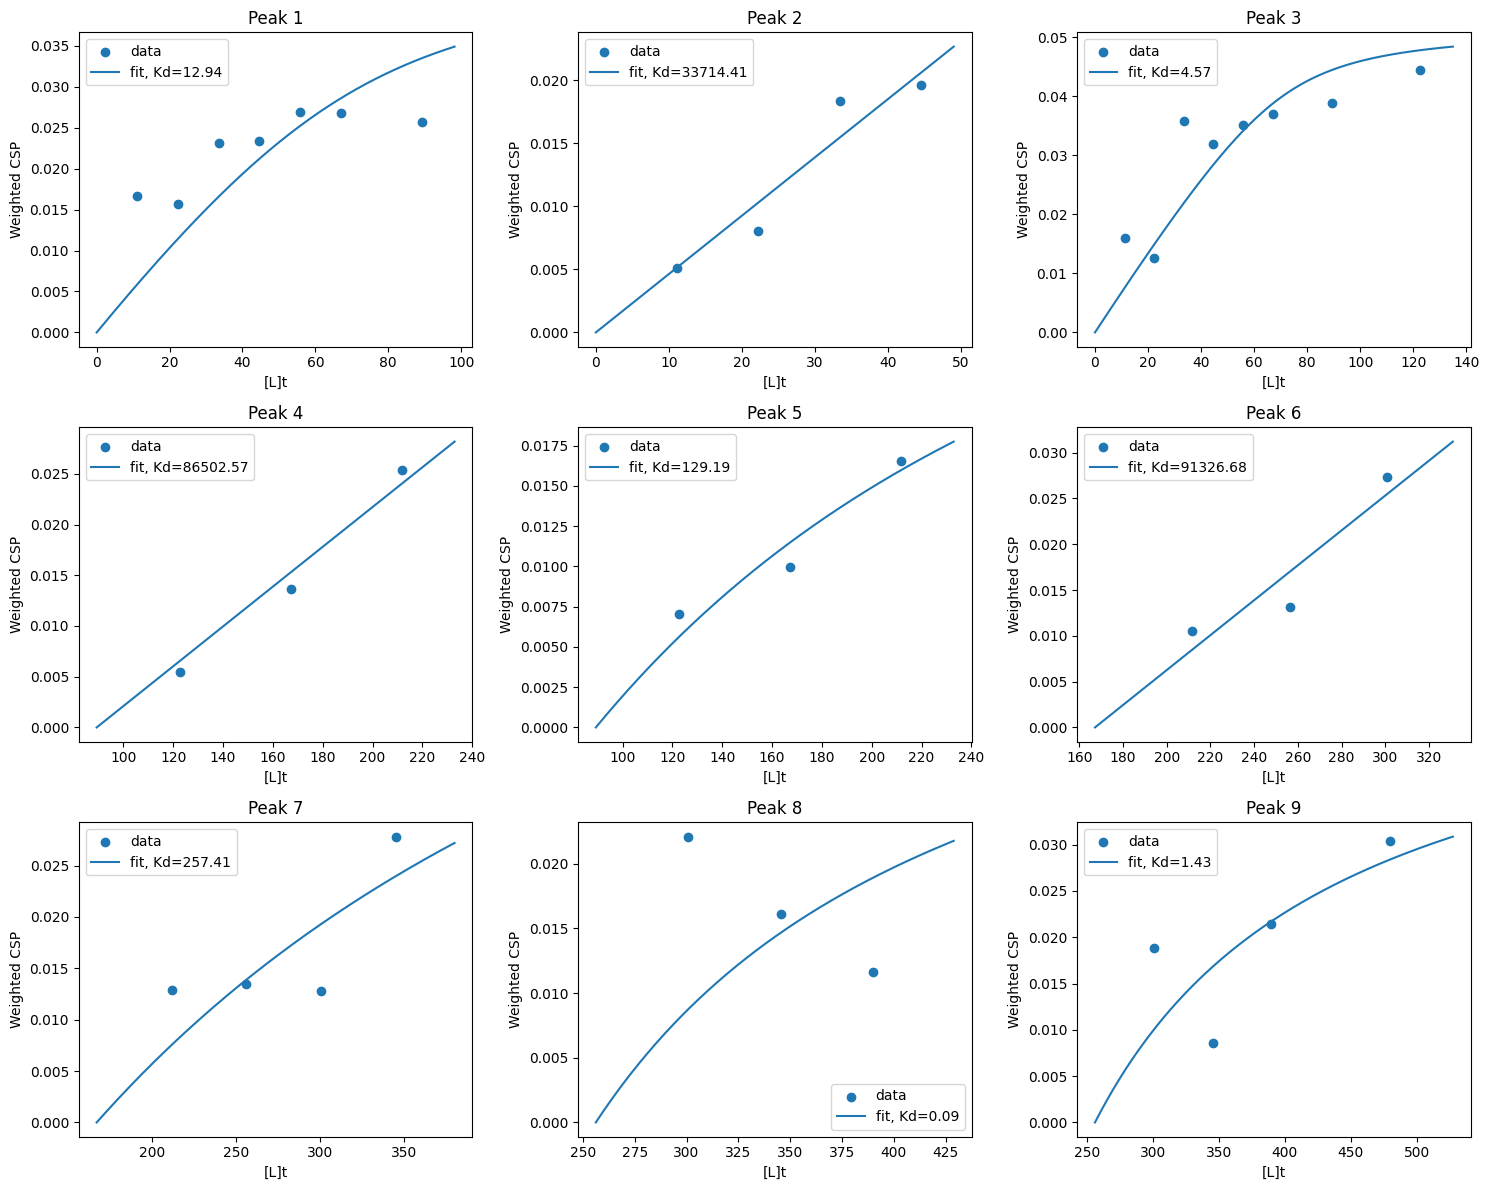

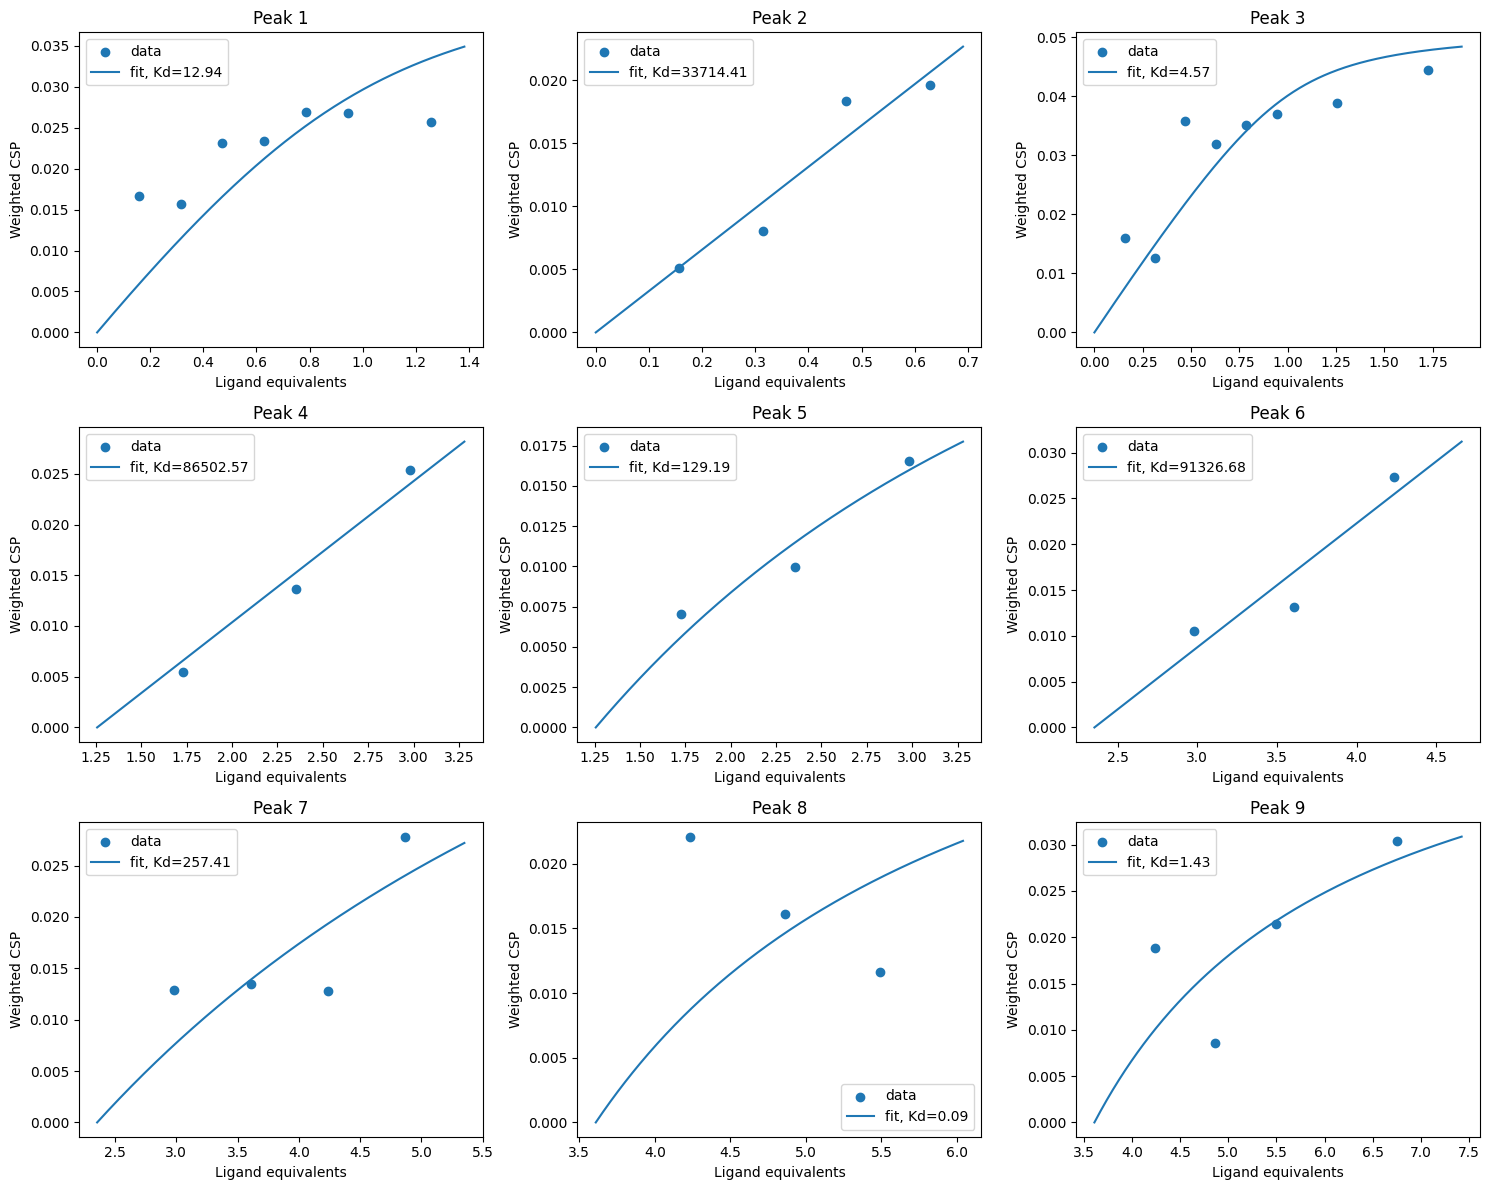

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ============================================================
# PARAMETRES GENERAUX
# ============================================================

# Concentration totale en protéine
# IMPORTANT: le Kd sera dans la même unité
Pt = 71.0   # [µM]

# Pondération 15N
alpha = 0.2   # équivaut à deltaN / 5

# Si tu veux la formule du paper avec sqrt(1/2), mets True
use_half_factor = True

# ============================================================
# DONNEES
# ref_equiv = équivalent à partir duquel les déplacements ont été mesurés
# ============================================================

data = {
    "Peak 1": {
        "ref_equiv": 0.000,
        "equiv":  [0.157, 0.314, 0.471, 0.628, 0.786, 0.943, 1.257],
        "deltaH": [0.0235, 0.0216, 0.0303, 0.0305, 0.0352, 0.0330, 0.0308],
        "deltaN": [0.0040, 0.0243, 0.0607, 0.0648, 0.0729, 0.0931, 0.0972],
    },
    "Peak 2": {
        "ref_equiv": 0.000,
        "equiv":  [0.157, 0.314, 0.471, 0.628],
        "deltaH": [0.0066, 0.0102, 0.0237, 0.0250],
        "deltaN": [0.0140, 0.0246, 0.0527, 0.0597],
    },
    "Peak 3": {
        "ref_equiv": 0.000,
        "equiv":  [0.157, 0.314, 0.471, 0.628, 0.786, 0.943, 1.257, 1.728],
        "deltaH": [0.00302, 0.00645, 0.01533, 0.02111, 0.01525, 0.02028, 0.02614, 0.03067],
        "deltaN": [0.11159, 0.08369, 0.24177, 0.19993, 0.23712, 0.24177, 0.24177, 0.27432],
    },
    "Peak 4": {
        "ref_equiv": 1.257,
        "equiv":  [1.728, 2.355, 2.982],
        "deltaH": [0.00491, 0.00771, 0.00014],
        "deltaN": [0.02938, 0.08814, 0.17974],
    },
    "Peak 5": {
        "ref_equiv": 1.257,
        "equiv":  [1.728, 2.355, 2.982],
        "deltaH": [0.00756, 0.01407, 0.01625],
        "deltaN": [0.03263, 0.00000, 0.08445],
    },
    "Peak 6": {
        "ref_equiv": 2.355,
        "equiv":  [2.982, 3.609, 4.236],
        "deltaH": [0.00769, 0.00392, 0.01866],
        "deltaN": [0.06361, 0.09087, 0.16962],
    },
    "Peak 7": {
        "ref_equiv": 2.355,
        "equiv":  [2.982, 3.609, 4.236, 4.864],
        "deltaH": [0.01736, 0.01845, 0.01790, 0.03933],
        "deltaN": [0.02838, 0.02390, 0.01344, 0.00000],
    },
    "Peak 8": {
        "ref_equiv": 3.609,
        "equiv":  [4.236, 4.864, 5.491],
        "deltaH": [0.03123, 0.01663, 0.01639],
        "deltaN": [0.00445, 0.07789, 0.00445],
    },
    "Peak 9": {
        "ref_equiv": 3.609,
        "equiv":  [4.236, 4.864, 5.491, 6.750],
        "deltaH": [0.02593, 0.01207, 0.03011, 0.04087],
        "deltaN": [0.03016, 0.00335, 0.01508, 0.06702],
    },
}

# ============================================================
# FONCTIONS
# ============================================================

def weighted_csp(deltaH, deltaN, alpha=0.2, use_half_factor=False):
    deltaH = np.asarray(deltaH, dtype=float)
    deltaN = np.asarray(deltaN, dtype=float)
    if use_half_factor:
        return np.sqrt(0.5 * (deltaH**2 + (alpha * deltaN)**2))
    return np.sqrt(deltaH**2 + (alpha * deltaN)**2)

def frac_bound(Lt, Kd, Pt):
    term = (Pt + Lt + Kd) - np.sqrt((Pt + Lt + Kd)**2 - 4.0 * Pt * Lt)
    return term / (2.0 * Pt)

def local_csp_model(Lt, Kd, dmax, Pt, Lt_ref):
    """
    Modèle adapté à des données mesurées par rapport à un point de référence Lt_ref
    """
    return dmax * (frac_bound(Lt, Kd, Pt) - frac_bound(Lt_ref, Kd, Pt))

def fit_one_peak(equiv, deltaH, deltaN, ref_equiv, Pt, alpha=0.2, use_half_factor=False):
    equiv = np.asarray(equiv, dtype=float)
    Lt = equiv * Pt
    Lt_ref = ref_equiv * Pt

    y = weighted_csp(deltaH, deltaN, alpha=alpha, use_half_factor=use_half_factor)

    def fit_func(Lt, Kd, dmax):
        return local_csp_model(Lt, Kd, dmax, Pt, Lt_ref)

    # guesses initiales
    p0 = [Pt, max(np.max(y) * 2.0, 1e-4)]

    # bornes
    bounds = ([1e-9, 0.0], [1e9, 100.0])

    popt, pcov = curve_fit(fit_func, Lt, y, p0=p0, bounds=bounds, maxfev=20000)
    Kd_fit, dmax_fit = popt
    perr = np.sqrt(np.diag(pcov))
    Kd_err, dmax_err = perr

    # qualité du fit
    y_fit = fit_func(Lt, *popt)
    ss_res = np.sum((y - y_fit)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    return {
        "equiv": equiv,
        "Lt": Lt,
        "Lt_ref": Lt_ref,
        "y": y,
        "Kd": Kd_fit,
        "Kd_err": Kd_err,
        "dmax": dmax_fit,
        "dmax_err": dmax_err,
        "r2": r2,
        "y_fit": y_fit,
    }

# ============================================================
# FIT DE TOUS LES PICS
# ============================================================

results = {}

for name, d in data.items():
    try:
        res = fit_one_peak(
            equiv=d["equiv"],
            deltaH=d["deltaH"],
            deltaN=d["deltaN"],
            ref_equiv=d["ref_equiv"],
            Pt=Pt,
            alpha=alpha,
            use_half_factor=use_half_factor
        )
        results[name] = res
    except Exception as e:
        print(f"{name}: fit failed -> {e}")

# ============================================================
# AFFICHAGE DES RESULTATS
# ============================================================

print("\n================ FIT RESULTS ================\n")
for name, res in results.items():
    print(f"{name}")
    print(f"  Kd    = {res['Kd']:.4f} ± {res['Kd_err']:.4f}")
    print(f"  dmax  = {res['dmax']:.6f} ± {res['dmax_err']:.6f} ppm")
    print(f"  R²    = {res['r2']:.4f}")
    print()

# ============================================================
# PLOTS INDIVIDUELS
# ============================================================

n = len(results)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = np.array(axes).reshape(-1)

for ax, (name, res) in zip(axes, results.items()):
    Lt_plot = np.linspace(min(res["Lt_ref"], res["Lt"].min()), res["Lt"].max() * 1.1, 300)
    y_plot = local_csp_model(Lt_plot, res["Kd"], res["dmax"], Pt, res["Lt_ref"])

    ax.scatter(res["Lt"], res["y"], label="data")
    ax.plot(Lt_plot, y_plot, label=f"fit, Kd={res['Kd']:.2f}")
    ax.set_title(name)
    ax.set_xlabel("[L]t")
    ax.set_ylabel("Weighted CSP")
    ax.legend()

# cacher les axes vides
for i in range(len(results), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# PLOT EN EQUIVALENTS (optionnel)
# ============================================================

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = np.array(axes).reshape(-1)

for ax, (name, res) in zip(axes, results.items()):
    equiv_plot = np.linspace(min(res["Lt_ref"] / Pt, res["equiv"].min()), res["equiv"].max() * 1.1, 300)
    Lt_plot = equiv_plot * Pt
    y_plot = local_csp_model(Lt_plot, res["Kd"], res["dmax"], Pt, res["Lt_ref"])

    ax.scatter(res["equiv"], res["y"], label="data")
    ax.plot(equiv_plot, y_plot, label=f"fit, Kd={res['Kd']:.2f}")
    ax.set_title(name)
    ax.set_xlabel("Ligand equivalents")
    ax.set_ylabel("Weighted CSP")
    ax.legend()

for i in range(len(results), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

### Golbat fit


================ GLOBAL FIT RESULTS ================

Kd global = 12.3306  (même unité que Pt)
Global R² = 0.6805

Peak 1
  dmax = 0.044855 ppm
  ref_equiv = 0.0

Peak 2
  dmax = 0.042420 ppm
  ref_equiv = 0.0

Peak 3
  dmax = 0.059179 ppm
  ref_equiv = 0.0

Peak 4
  dmax = 0.114376 ppm
  ref_equiv = 1.257

Peak 5
  dmax = 0.082435 ppm
  ref_equiv = 1.257

Peak 6
  dmax = 0.405221 ppm
  ref_equiv = 2.355

Peak 7
  dmax = 0.344938 ppm
  ref_equiv = 2.355

Peak 8
  dmax = 0.784687 ppm
  ref_equiv = 3.609

Peak 9
  dmax = 0.897520 ppm
  ref_equiv = 3.609



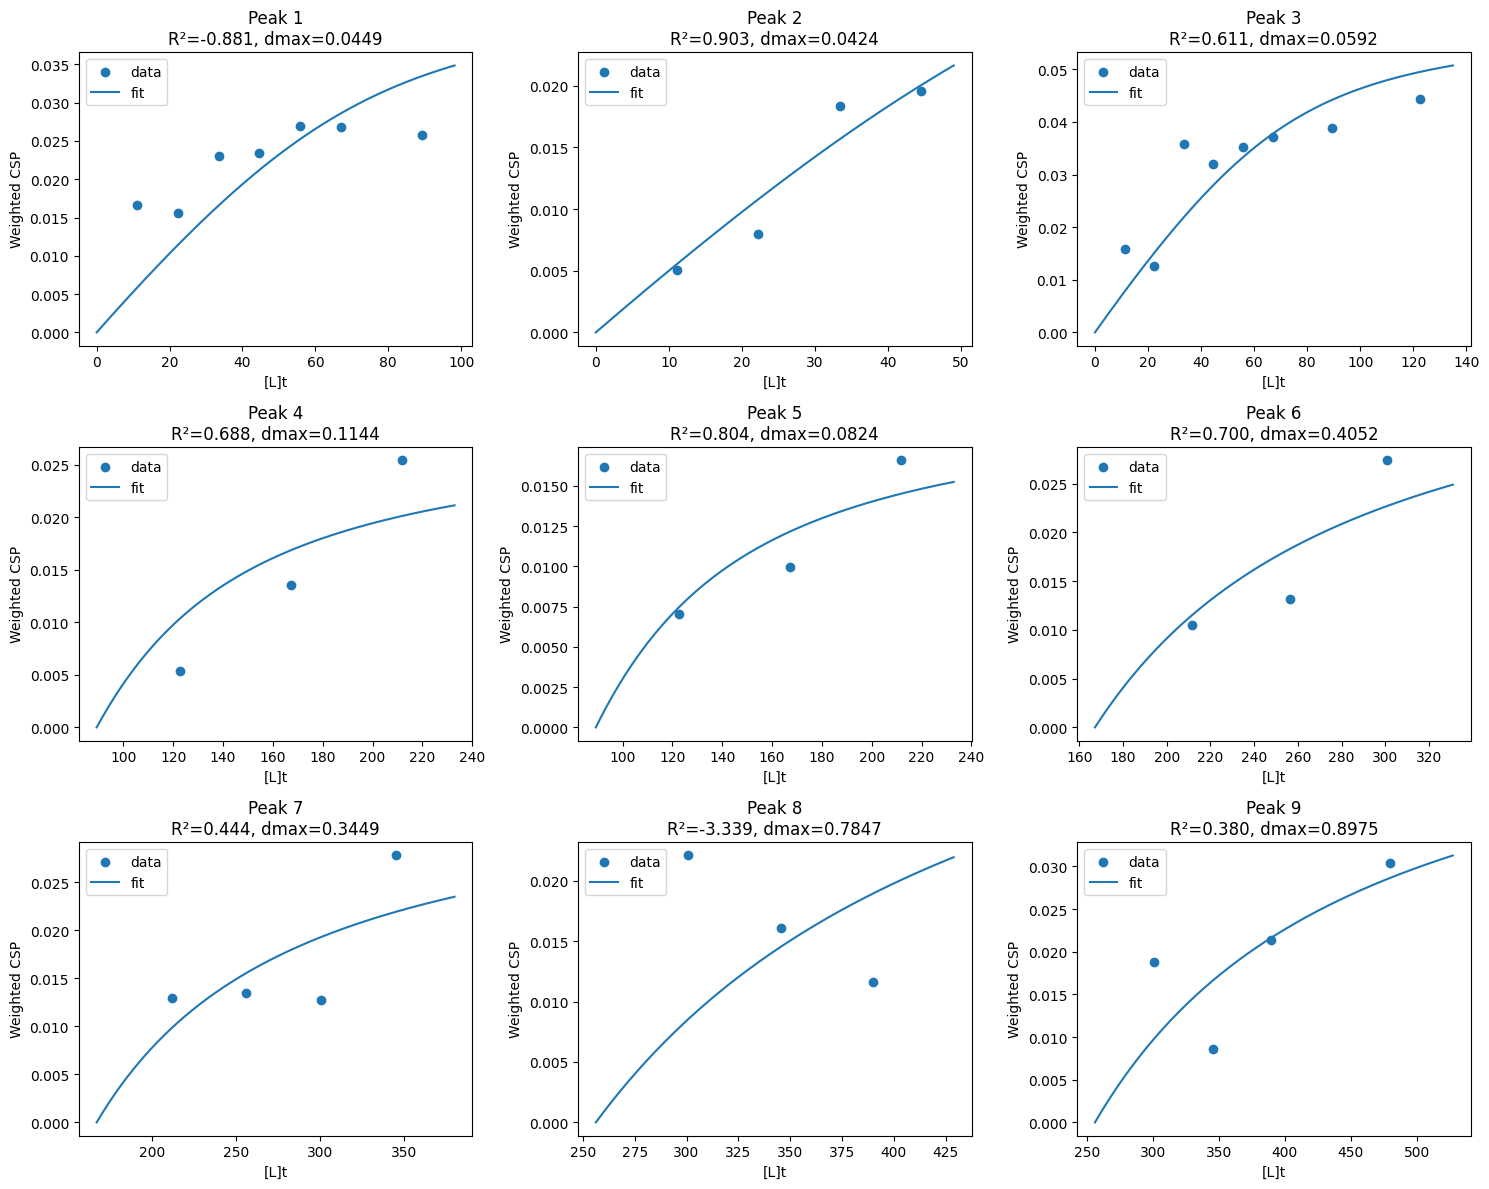

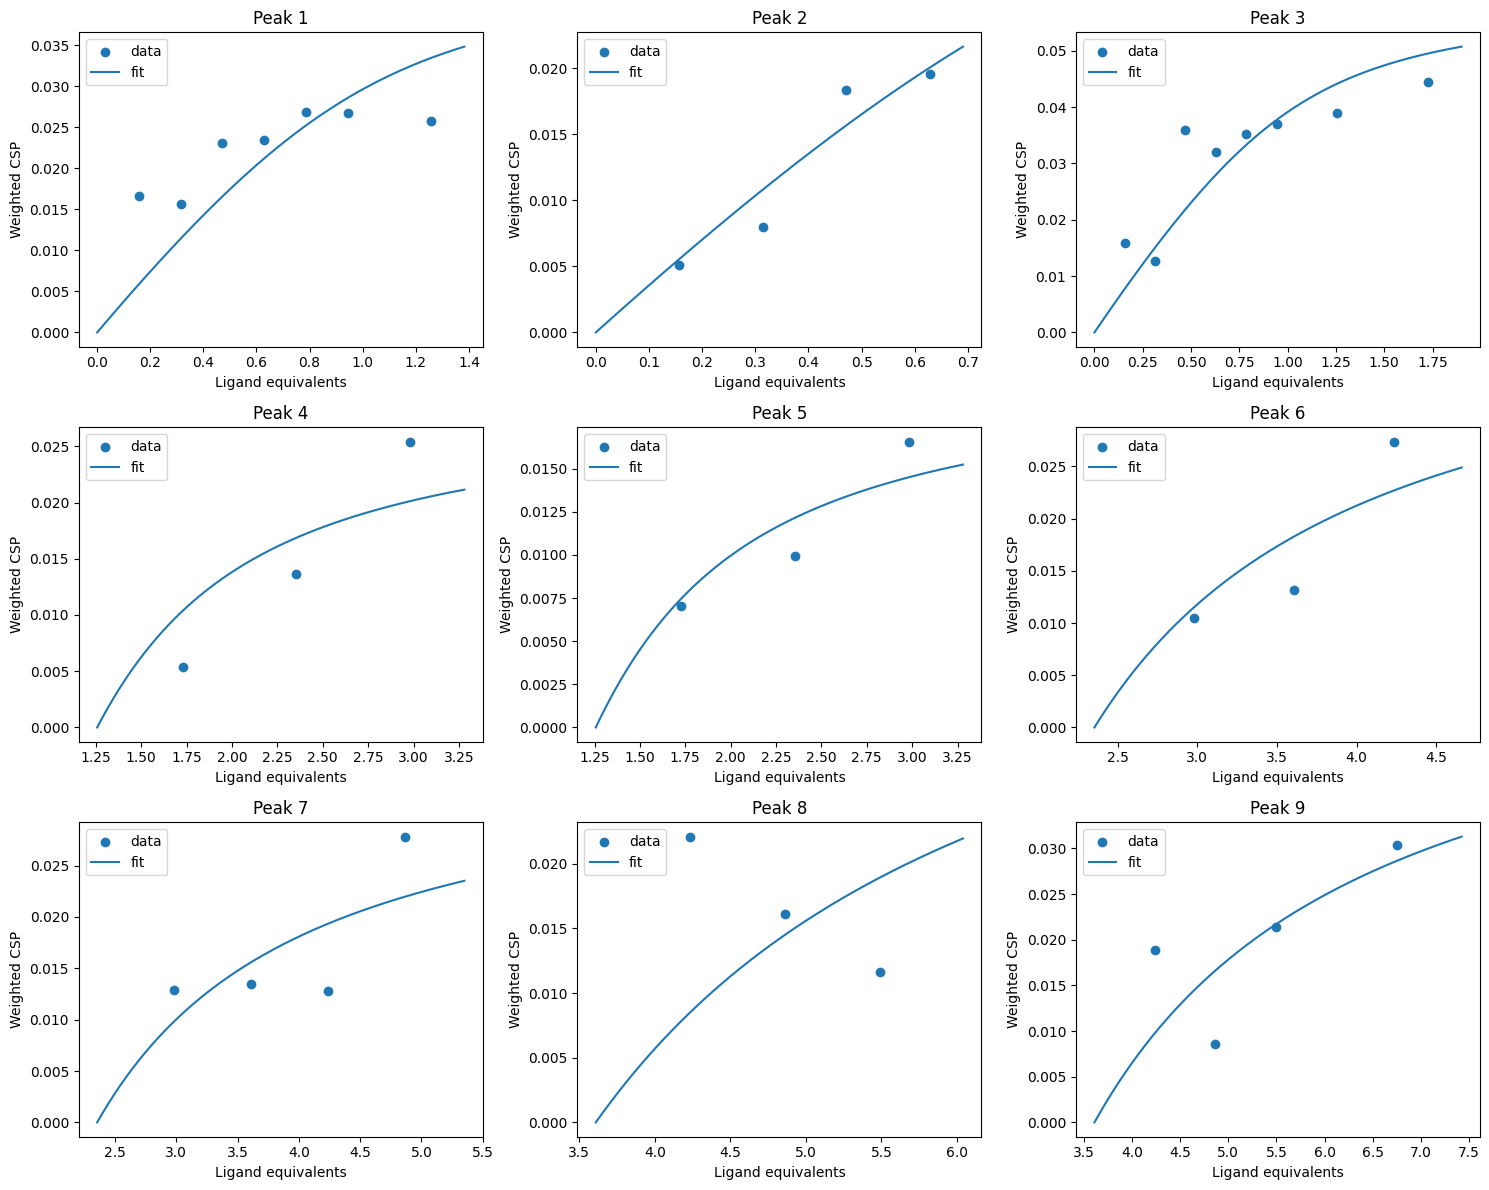

Results written to global_fit_results.txt


In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

# ============================================================
# PARAMETRES GENERAUX
# ============================================================

# Concentration totale en protéine
# Le Kd sortira dans la même unité
Pt = 71.0   # ex: 50 µM

# Pondération du 15N
alpha = 0.2   # équivaut à deltaN / 5

# Si tu veux inclure le facteur 1/2 du paper, mets True
use_half_factor = True

# ============================================================
# DONNEES
# ref_equiv = équivalent à partir duquel les déplacements ont été mesurés
# ============================================================

data = {
    "Peak 1": {
        "ref_equiv": 0.000,
        "equiv":  [0.157, 0.314, 0.471, 0.628, 0.786, 0.943, 1.257],
        "deltaH": [0.0235, 0.0216, 0.0303, 0.0305, 0.0352, 0.0330, 0.0308],
        "deltaN": [0.0040, 0.0243, 0.0607, 0.0648, 0.0729, 0.0931, 0.0972],
    },
    "Peak 2": {
        "ref_equiv": 0.000,
        "equiv":  [0.157, 0.314, 0.471, 0.628],
        "deltaH": [0.0066, 0.0102, 0.0237, 0.0250],
        "deltaN": [0.0140, 0.0246, 0.0527, 0.0597],
    },
    "Peak 3": {
        "ref_equiv": 0.000,
        "equiv":  [0.157, 0.314, 0.471, 0.628, 0.786, 0.943, 1.257, 1.728],
        "deltaH": [0.00302, 0.00645, 0.01533, 0.02111, 0.01525, 0.02028, 0.02614, 0.03067],
        "deltaN": [0.11159, 0.08369, 0.24177, 0.19993, 0.23712, 0.24177, 0.24177, 0.27432],
    },
    "Peak 4": {
        "ref_equiv": 1.257,
        "equiv":  [1.728, 2.355, 2.982],
        "deltaH": [0.00491, 0.00771, 0.00014],
        "deltaN": [0.02938, 0.08814, 0.17974],
    },
    "Peak 5": {
        "ref_equiv": 1.257,
        "equiv":  [1.728, 2.355, 2.982],
        "deltaH": [0.00756, 0.01407, 0.01625],
        "deltaN": [0.03263, 0.00000, 0.08445],
    },
    "Peak 6": {
        "ref_equiv": 2.355,
        "equiv":  [2.982, 3.609, 4.236],
        "deltaH": [0.00769, 0.00392, 0.01866],
        "deltaN": [0.06361, 0.09087, 0.16962],
    },
    "Peak 7": {
        "ref_equiv": 2.355,
        "equiv":  [2.982, 3.609, 4.236, 4.864],
        "deltaH": [0.01736, 0.01845, 0.01790, 0.03933],
        "deltaN": [0.02838, 0.02390, 0.01344, 0.00000],
    },
    "Peak 8": {
        "ref_equiv": 3.609,
        "equiv":  [4.236, 4.864, 5.491],
        "deltaH": [0.03123, 0.01663, 0.01639],
        "deltaN": [0.00445, 0.07789, 0.00445],
    },
    "Peak 9": {
        "ref_equiv": 3.609,
        "equiv":  [4.236, 4.864, 5.491, 6.750],
        "deltaH": [0.02593, 0.01207, 0.03011, 0.04087],
        "deltaN": [0.03016, 0.00335, 0.01508, 0.06702],
    },
}

# ============================================================
# FONCTIONS
# ============================================================

def weighted_csp(deltaH, deltaN, alpha=0.2, use_half_factor=False):
    deltaH = np.asarray(deltaH, dtype=float)
    deltaN = np.asarray(deltaN, dtype=float)
    if use_half_factor:
        return np.sqrt(0.5 * (deltaH**2 + (alpha * deltaN)**2))
    return np.sqrt(deltaH**2 + (alpha * deltaN)**2)

def frac_bound(Lt, Kd, Pt):
    term = (Pt + Lt + Kd) - np.sqrt((Pt + Lt + Kd)**2 - 4.0 * Pt * Lt)
    return term / (2.0 * Pt)

def local_model(Lt, Kd, dmax, Pt, Lt_ref):
    return dmax * (frac_bound(Lt, Kd, Pt) - frac_bound(Lt_ref, Kd, Pt))

# Préparation des données
peak_names = list(data.keys())
y_exp = {}
Lt_vals = {}
Lt_refs = {}

for name, d in data.items():
    equiv = np.asarray(d["equiv"], dtype=float)
    deltaH = np.asarray(d["deltaH"], dtype=float)
    deltaN = np.asarray(d["deltaN"], dtype=float)

    y_exp[name] = weighted_csp(deltaH, deltaN, alpha=alpha, use_half_factor=use_half_factor)
    Lt_vals[name] = equiv * Pt
    Lt_refs[name] = d["ref_equiv"] * Pt

# ============================================================
# GLOBAL FIT
# paramètre global = Kd
# paramètres locaux = dmax pour chaque pic
# params = [Kd, dmax_1, dmax_2, ..., dmax_n]
# ============================================================

def residuals(params):
    Kd = params[0]
    dmax_list = params[1:]

    res = []
    for i, name in enumerate(peak_names):
        dmax = dmax_list[i]
        y_calc = local_model(Lt_vals[name], Kd, dmax, Pt, Lt_refs[name])
        res.extend(y_calc - y_exp[name])
    return np.array(res)

# Guess initial
Kd_guess = Pt
dmax_guesses = [max(np.max(y_exp[name]) * 2.0, 1e-4) for name in peak_names]
x0 = np.array([Kd_guess] + dmax_guesses)

# Bornes
lower_bounds = [1e-9] + [0.0] * len(peak_names)
upper_bounds = [1e9] + [100.0] * len(peak_names)

result = least_squares(
    residuals,
    x0=x0,
    bounds=(lower_bounds, upper_bounds),
    max_nfev=50000
)

params_fit = result.x
Kd_global = params_fit[0]
dmax_global = params_fit[1:]

# ============================================================
# CALCUL D'UN R² GLOBAL
# ============================================================

all_exp = []
all_fit = []

for i, name in enumerate(peak_names):
    y_fit = local_model(Lt_vals[name], Kd_global, dmax_global[i], Pt, Lt_refs[name])
    all_exp.extend(y_exp[name])
    all_fit.extend(y_fit)

all_exp = np.array(all_exp)
all_fit = np.array(all_fit)

ss_res = np.sum((all_exp - all_fit)**2)
ss_tot = np.sum((all_exp - np.mean(all_exp))**2)
r2_global = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

# ============================================================
# AFFICHAGE DES RESULTATS
# ============================================================

print("\n================ GLOBAL FIT RESULTS ================\n")
print(f"Kd global = {Kd_global:.4f}  (même unité que Pt)")
print(f"Global R² = {r2_global:.4f}\n")

for i, name in enumerate(peak_names):
    print(f"{name}")
    print(f"  dmax = {dmax_global[i]:.6f} ppm")
    print(f"  ref_equiv = {data[name]['ref_equiv']}")
    print()

# ============================================================
# PLOTS INDIVIDUELS
# ============================================================

n = len(peak_names)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = np.array(axes).reshape(-1)

for ax, name, dmax in zip(axes, peak_names, dmax_global):
    Lt_min = min(Lt_refs[name], np.min(Lt_vals[name]))
    Lt_max = np.max(Lt_vals[name]) * 1.1
    Lt_plot = np.linspace(Lt_min, Lt_max, 300)

    y_plot = local_model(Lt_plot, Kd_global, dmax, Pt, Lt_refs[name])
    y_fit_pts = local_model(Lt_vals[name], Kd_global, dmax, Pt, Lt_refs[name])

    # R² local indicatif
    y = y_exp[name]
    ss_res_local = np.sum((y - y_fit_pts)**2)
    ss_tot_local = np.sum((y - np.mean(y))**2)
    r2_local = 1 - ss_res_local / ss_tot_local if ss_tot_local > 0 else np.nan

    ax.scatter(Lt_vals[name], y_exp[name], label="data")
    ax.plot(Lt_plot, y_plot, label=f"fit")
    ax.set_title(f"{name}\nR²={r2_local:.3f}, dmax={dmax:.4f}")
    ax.set_xlabel("[L]t")
    ax.set_ylabel("Weighted CSP")
    ax.legend()

for i in range(len(peak_names), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# VERSION AVEC AXE EN EQUIVALENTS
# ============================================================

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = np.array(axes).reshape(-1)

for ax, name, dmax in zip(axes, peak_names, dmax_global):
    eq_min = min(data[name]["ref_equiv"], np.min(data[name]["equiv"]))
    eq_max = np.max(data[name]["equiv"]) * 1.1
    eq_plot = np.linspace(eq_min, eq_max, 300)
    Lt_plot = eq_plot * Pt

    y_plot = local_model(Lt_plot, Kd_global, dmax, Pt, Lt_refs[name])

    ax.scatter(data[name]["equiv"], y_exp[name], label="data")
    ax.plot(eq_plot, y_plot, label=f"fit")
    ax.set_title(f"{name}")
    ax.set_xlabel("Ligand equivalents")
    ax.set_ylabel("Weighted CSP")
    ax.legend()

for i in range(len(peak_names), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# SAUVEGARDE TEXTE
# ============================================================

with open("global_fit_results_equiv_corr.txt", "w", encoding="utf-8") as f:
    f.write("================ GLOBAL FIT RESULTS ================\n\n")
    f.write(f"Kd global = {Kd_global:.6f} (same unit as Pt)\n")
    f.write(f"Global R² = {r2_global:.6f}\n\n")
    for i, name in enumerate(peak_names):
        f.write(f"{name}\n")
        f.write(f"  dmax = {dmax_global[i]:.6f} ppm\n")
        f.write(f"  ref_equiv = {data[name]['ref_equiv']}\n\n")

print("Results written to global_fit_results.txt")


================ GLOBAL FIT RESULTS ================

Kd global = 12.0994  (même unité que Pt)
Global R² = 0.7734

Peak 1
  dmax = 0.044689 ppm
  ref_equiv = 0.0

Peak 2
  dmax = 0.042265 ppm
  ref_equiv = 0.0

Peak 3
  dmax = 0.058980 ppm
  ref_equiv = 0.0

Peak 4
  dmax = 0.115100 ppm
  ref_equiv = 1.257

Peak 5
  dmax = 0.082973 ppm
  ref_equiv = 1.257



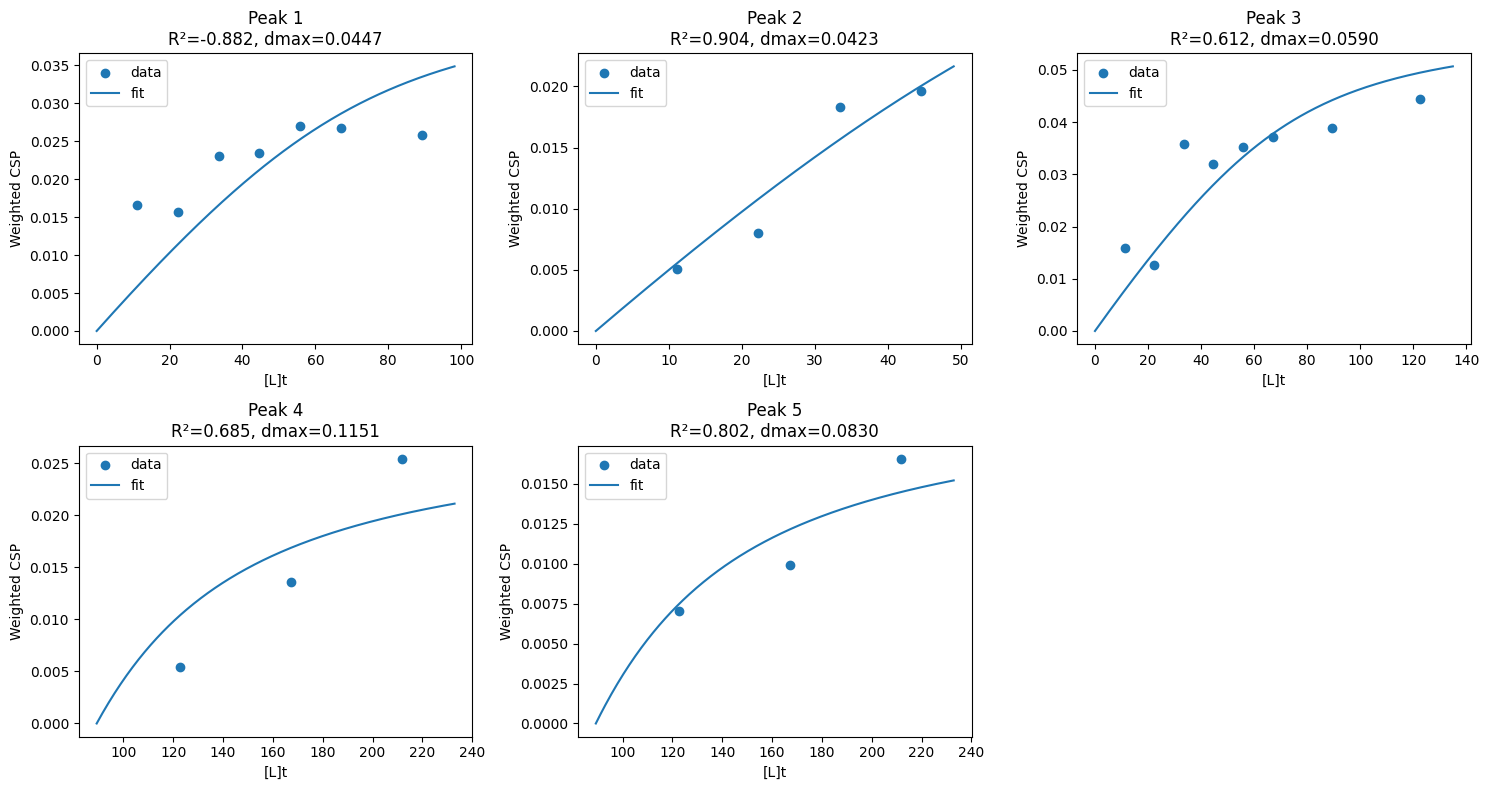

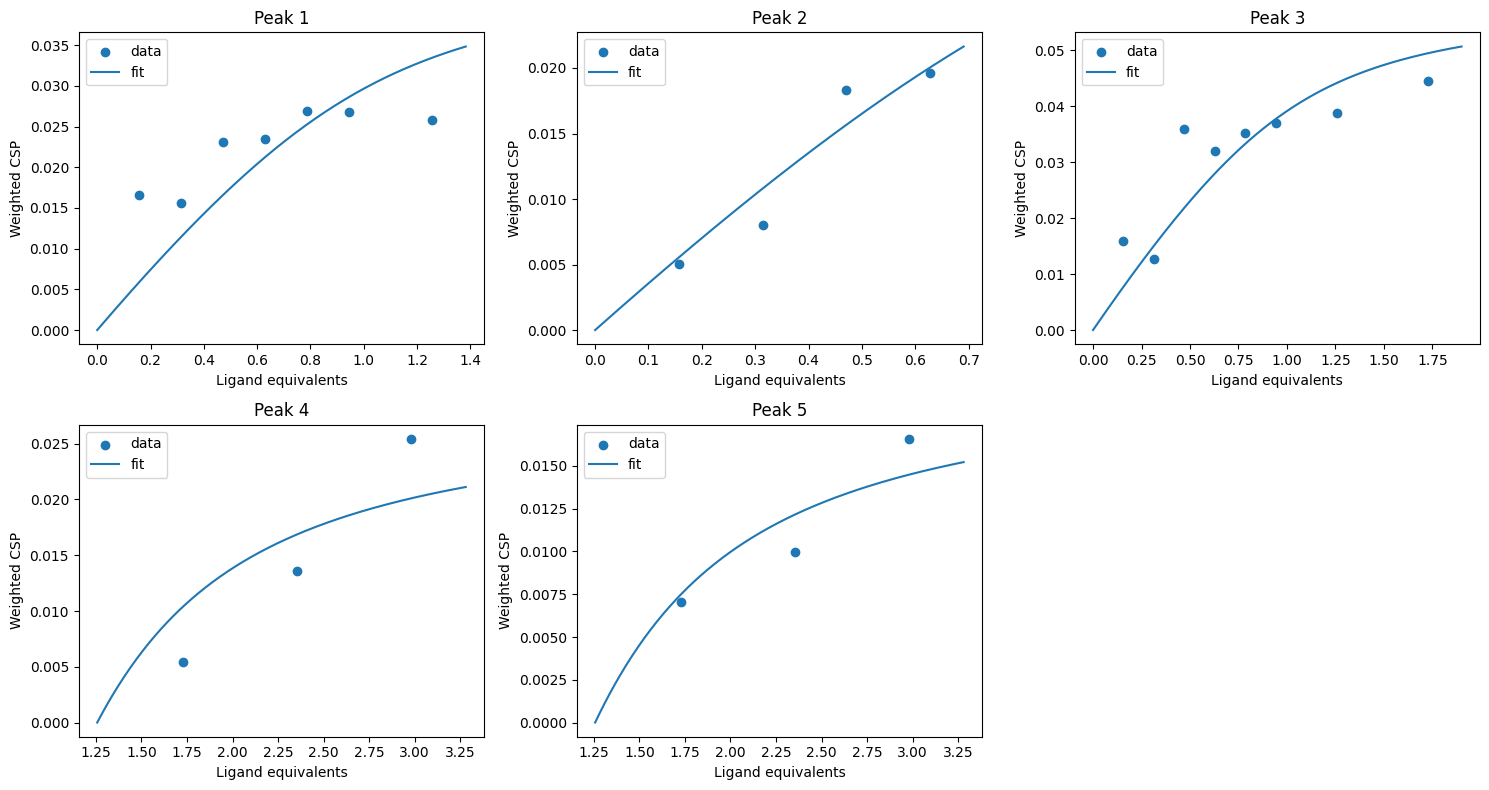

Results written to global_fit_results.txt


In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

# ============================================================
# PARAMETRES GENERAUX
# ============================================================

# Concentration totale en protéine
# Le Kd sortira dans la même unité
Pt = 71.0   # ex: 50 µM

# Pondération du 15N
alpha = 0.2   # équivaut à deltaN / 5

# Si tu veux inclure le facteur 1/2 du paper, mets True
use_half_factor = True

# ============================================================
# DONNEES
# ref_equiv = équivalent à partir duquel les déplacements ont été mesurés
# ============================================================

data = {
    "Peak 1": {
        "ref_equiv": 0.000,
        "equiv":  [0.157, 0.314, 0.471, 0.628, 0.786, 0.943, 1.257],
        "deltaH": [0.0235, 0.0216, 0.0303, 0.0305, 0.0352, 0.0330, 0.0308],
        "deltaN": [0.0040, 0.0243, 0.0607, 0.0648, 0.0729, 0.0931, 0.0972],
    },
    "Peak 2": {
        "ref_equiv": 0.000,
        "equiv":  [0.157, 0.314, 0.471, 0.628],
        "deltaH": [0.0066, 0.0102, 0.0237, 0.0250],
        "deltaN": [0.0140, 0.0246, 0.0527, 0.0597],
    },
    "Peak 3": {
        "ref_equiv": 0.000,
        "equiv":  [0.157, 0.314, 0.471, 0.628, 0.786, 0.943, 1.257, 1.728],
        "deltaH": [0.00302, 0.00645, 0.01533, 0.02111, 0.01525, 0.02028, 0.02614, 0.03067],
        "deltaN": [0.11159, 0.08369, 0.24177, 0.19993, 0.23712, 0.24177, 0.24177, 0.27432],
    },
    "Peak 4": {
        "ref_equiv": 1.257,
        "equiv":  [1.728, 2.355, 2.982],
        "deltaH": [0.00491, 0.00771, 0.00014],
        "deltaN": [0.02938, 0.08814, 0.17974],
    },
    "Peak 5": {
        "ref_equiv": 1.257,
        "equiv":  [1.728, 2.355, 2.982],
        "deltaH": [0.00756, 0.01407, 0.01625],
        "deltaN": [0.03263, 0.00000, 0.08445],
    },
}

# ============================================================
# FONCTIONS
# ============================================================

def weighted_csp(deltaH, deltaN, alpha=0.2, use_half_factor=False):
    deltaH = np.asarray(deltaH, dtype=float)
    deltaN = np.asarray(deltaN, dtype=float)
    if use_half_factor:
        return np.sqrt(0.5 * (deltaH**2 + (alpha * deltaN)**2))
    return np.sqrt(deltaH**2 + (alpha * deltaN)**2)

def frac_bound(Lt, Kd, Pt):
    term = (Pt + Lt + Kd) - np.sqrt((Pt + Lt + Kd)**2 - 4.0 * Pt * Lt)
    return term / (2.0 * Pt)

def local_model(Lt, Kd, dmax, Pt, Lt_ref):
    return dmax * (frac_bound(Lt, Kd, Pt) - frac_bound(Lt_ref, Kd, Pt))

# Préparation des données
peak_names = list(data.keys())
y_exp = {}
Lt_vals = {}
Lt_refs = {}

for name, d in data.items():
    equiv = np.asarray(d["equiv"], dtype=float)
    deltaH = np.asarray(d["deltaH"], dtype=float)
    deltaN = np.asarray(d["deltaN"], dtype=float)

    y_exp[name] = weighted_csp(deltaH, deltaN, alpha=alpha, use_half_factor=use_half_factor)
    Lt_vals[name] = equiv * Pt
    Lt_refs[name] = d["ref_equiv"] * Pt

# ============================================================
# GLOBAL FIT
# paramètre global = Kd
# paramètres locaux = dmax pour chaque pic
# params = [Kd, dmax_1, dmax_2, ..., dmax_n]
# ============================================================

def residuals(params):
    Kd = params[0]
    dmax_list = params[1:]

    res = []
    for i, name in enumerate(peak_names):
        dmax = dmax_list[i]
        y_calc = local_model(Lt_vals[name], Kd, dmax, Pt, Lt_refs[name])
        res.extend(y_calc - y_exp[name])
    return np.array(res)

# Guess initial
Kd_guess = Pt
dmax_guesses = [max(np.max(y_exp[name]) * 2.0, 1e-4) for name in peak_names]
x0 = np.array([Kd_guess] + dmax_guesses)

# Bornes
lower_bounds = [1e-9] + [0.0] * len(peak_names)
upper_bounds = [1e9] + [100.0] * len(peak_names)

result = least_squares(
    residuals,
    x0=x0,
    bounds=(lower_bounds, upper_bounds),
    max_nfev=50000
)

params_fit = result.x
Kd_global = params_fit[0]
dmax_global = params_fit[1:]

# ============================================================
# CALCUL D'UN R² GLOBAL
# ============================================================

all_exp = []
all_fit = []

for i, name in enumerate(peak_names):
    y_fit = local_model(Lt_vals[name], Kd_global, dmax_global[i], Pt, Lt_refs[name])
    all_exp.extend(y_exp[name])
    all_fit.extend(y_fit)

all_exp = np.array(all_exp)
all_fit = np.array(all_fit)

ss_res = np.sum((all_exp - all_fit)**2)
ss_tot = np.sum((all_exp - np.mean(all_exp))**2)
r2_global = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

# ============================================================
# AFFICHAGE DES RESULTATS
# ============================================================

print("\n================ GLOBAL FIT RESULTS ================\n")
print(f"Kd global = {Kd_global:.4f}  (même unité que Pt)")
print(f"Global R² = {r2_global:.4f}\n")

for i, name in enumerate(peak_names):
    print(f"{name}")
    print(f"  dmax = {dmax_global[i]:.6f} ppm")
    print(f"  ref_equiv = {data[name]['ref_equiv']}")
    print()

# ============================================================
# PLOTS INDIVIDUELS
# ============================================================

n = len(peak_names)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = np.array(axes).reshape(-1)

for ax, name, dmax in zip(axes, peak_names, dmax_global):
    Lt_min = min(Lt_refs[name], np.min(Lt_vals[name]))
    Lt_max = np.max(Lt_vals[name]) * 1.1
    Lt_plot = np.linspace(Lt_min, Lt_max, 300)

    y_plot = local_model(Lt_plot, Kd_global, dmax, Pt, Lt_refs[name])
    y_fit_pts = local_model(Lt_vals[name], Kd_global, dmax, Pt, Lt_refs[name])

    # R² local indicatif
    y = y_exp[name]
    ss_res_local = np.sum((y - y_fit_pts)**2)
    ss_tot_local = np.sum((y - np.mean(y))**2)
    r2_local = 1 - ss_res_local / ss_tot_local if ss_tot_local > 0 else np.nan

    ax.scatter(Lt_vals[name], y_exp[name], label="data")
    ax.plot(Lt_plot, y_plot, label=f"fit")
    ax.set_title(f"{name}\nR²={r2_local:.3f}, dmax={dmax:.4f}")
    ax.set_xlabel("[L]t")
    ax.set_ylabel("Weighted CSP")
    ax.legend()

for i in range(len(peak_names), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# VERSION AVEC AXE EN EQUIVALENTS
# ============================================================

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = np.array(axes).reshape(-1)

for ax, name, dmax in zip(axes, peak_names, dmax_global):
    eq_min = min(data[name]["ref_equiv"], np.min(data[name]["equiv"]))
    eq_max = np.max(data[name]["equiv"]) * 1.1
    eq_plot = np.linspace(eq_min, eq_max, 300)
    Lt_plot = eq_plot * Pt

    y_plot = local_model(Lt_plot, Kd_global, dmax, Pt, Lt_refs[name])

    ax.scatter(data[name]["equiv"], y_exp[name], label="data")
    ax.plot(eq_plot, y_plot, label=f"fit")
    ax.set_title(f"{name}")
    ax.set_xlabel("Ligand equivalents")
    ax.set_ylabel("Weighted CSP")
    ax.legend()

for i in range(len(peak_names), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# SAUVEGARDE TEXTE
# ============================================================

with open("global_fit_results_pic1to5.txt", "w", encoding="utf-8") as f:
    f.write("================ GLOBAL FIT RESULTS ================\n\n")
    f.write(f"Kd global = {Kd_global:.6f} (same unit as Pt)\n")
    f.write(f"Global R² = {r2_global:.6f}\n\n")
    for i, name in enumerate(peak_names):
        f.write(f"{name}\n")
        f.write(f"  dmax = {dmax_global[i]:.6f} ppm\n")
        f.write(f"  ref_equiv = {data[name]['ref_equiv']}\n\n")

print("Results written to global_fit_results.txt")